**Paper 1 Figures - Sep 9, 2026**

In [1]:
%pip install pandas matplotlib numpy scikit-learn psycopg2-binary

/Users/pegah/Projects/lemurs-modeling/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
!uv pip install matplotlib

Using Python 3.13.9 environment at: /Users/pegah/Projects/lemurs-modeling/.venv
Checked 1 package in 39ms


In [3]:
import os

print(os.path.exists("../src"))
print(os.listdir("..")[:20])

True
['demographics_analysis.ipynb', 'requirements.txt', 'uv.lock', '.pre-commit-config.yaml', 'check.ipynb', 'Makefile', 'paperfig.ipynb', 'pyproject.toml', 'tests', 'ema_response_rate.pdf', 'README.md', 'setup.py', 'logs', 'demographicswithlabel.xlsx', '.gitignore', '.env', 'configs', '.venv', 'scripts', '.github']


In [4]:
os.chdir('/Users/pegah/Projects/lemurs-modeling')

In [5]:
import os
print(os.getcwd())

/Users/pegah/Projects/lemurs-modeling


In [6]:
#importing the database
from src.utils.database_service import DatabaseService


In [7]:
db = DatabaseService() 

In [8]:
dir(db)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__enter__',
 '__eq__',
 '__exit__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_resolve_ssh_pkey',
 'connect',
 'connection',
 'dbname',
 'disconnect',
 'extract_from_database',
 'host',
 'password',
 'port',
 'ssh_host',
 'ssh_key',
 'ssh_password',
 'ssh_pkey',
 'ssh_port',
 'ssh_user',
 'tunnel',
 'user']

In [9]:
db.connect() #connecting to the DB

True

In [10]:
tables = db.extract_from_database("information_schema.tables")
tables

,table_catalog,table_schema,table_name,table_type,self_referencing_column_name,reference_generation,user_defined_type_catalog,user_defined_type_schema,user_defined_type_name,is_insertable_into,is_typed,commit_action
0,lemurs,public,app_user,BASE TABLE,None,None,None,None,None,YES,NO,None
1,lemurs,public,umass_id,BASE TABLE,None,None,None,None,None,YES,NO,None
2,lemurs,public,user_info,BASE TABLE,None,None,None,None,None,YES,NO,None
3,lemurs,public,auth_microsoft,BASE TABLE,None,None,None,None,None,YES,NO,None
4,lemurs,public,authorized_email,BASE TABLE,None,None,None,None,None,YES,NO,None
...,...,...,...,...,...,...,...,...,...,...,...,...
243,lemurs,public,danger_alert,BASE TABLE,None,None,None,None,None,YES,NO,None
244,lemurs,public,all_danger_alert,VIEW,None,None,None,None,None,NO,NO,None
245,lemurs,public,missing_daily_surveys,VIEW,None,None,None,None,None,NO,NO,None
246,lemurs,public,danger_alert_trigger,BASE TABLE,None,None,None,None,None,YES,NO,None


In [11]:
#table names
tables["table_name"].tolist()

['app_user',
 'umass_id',
 'user_info',
 'auth_microsoft',
 'authorized_email',
 'authorized_email_elevated',
 'app_role',
 'data',
 'pg_statistic',
 'pg_type',
 'danger_alert_email',
 'question',
 'survey',
 'survey_question',
 'survey_question_view',
 'pg_foreign_table',
 'survey_response',
 'pg_authid',
 'pg_shadow',
 'answer',
 'progress',
 'pg_roles',
 'incentive',
 'goal_progress',
 'goal',
 'pg_statistic_ext_data',
 'survey_availability',
 'calorie',
 'pg_hba_file_rules',
 'pg_settings',
 'pg_file_settings',
 'pg_backend_memory_contexts',
 'pg_ident_file_mappings',
 'speed',
 'pg_config',
 'pg_shmem_allocations',
 'pg_tables',
 'screentime',
 'screentime_app',
 'audio',
 'audio_response',
 'combined_data',
 'pg_user_mapping',
 'pg_statio_all_sequences',
 'pg_replication_origin_status',
 'pg_subscription',
 'pg_attribute',
 'pg_proc',
 'pg_class',
 'pg_attrdef',
 'pg_statio_sys_sequences',
 'pg_statio_user_sequences',
 'pg_constraint',
 'pg_inherits',
 'pg_index',
 'pg_operator',

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [13]:
#Excluding global users based on src/data/components/cohort_builder.py

import pandas as pd
import numpy as np

# GLOBAL USER EXCLUSIONS

#filter user ids (8 users currently) 
# * I alsoadded app_user_id = 12
DEFAULT_EXCLUDED_USER_IDS = [1, 2, 3, 10, 12, 21, 22, 43, 44]


print("excluded users:", DEFAULT_EXCLUDED_USER_IDS)


excluded users: [1, 2, 3, 10, 12, 21, 22, 43, 44]


In [14]:
#function for removing excluded users
def remove_excluded_users(df, exclude_ids=DEFAULT_EXCLUDED_USER_IDS):
    if not exclude_ids or df.empty:
        return df.copy()

    return df.loc[~df["app_user_id"].isin(exclude_ids)].copy()

In [15]:
step=db.extract_from_database("step")
calorie = db.extract_from_database("calorie")
distance=db.extract_from_database("distance")
#calorie.head()
#calorie.shape

In [16]:
step

,id,app_user_id,steps,start_timestamp,end_timestamp,app_source,recorded_date,type,additional_data,status
0,1,6,53,2025-11-18 18:03:36.149,2025-11-18 18:05:22.150,androidx.health.connect.client.records.metadat...,2025-11-18 18:09:33.714,steps,{},0
1,2,7,51,2025-11-24 19:37:10.371,2025-11-24 19:38:52.372,androidx.health.connect.client.records.metadat...,2025-11-24 19:48:49.383,steps,{},0
2,3,7,24,2025-11-24 19:38:52.371,2025-11-24 19:39:09.138,androidx.health.connect.client.records.metadat...,2025-11-24 19:48:49.748,steps,{},0
3,4,7,35,2025-11-24 19:39:09.137,2025-11-24 19:39:50.102,androidx.health.connect.client.records.metadat...,2025-11-24 19:48:50.185,steps,{},0
4,5,7,65,2025-11-24 19:39:50.101,2025-11-24 19:40:50.675,androidx.health.connect.client.records.metadat...,2025-11-24 19:48:50.702,steps,{},0
...,...,...,...,...,...,...,...,...,...,...
15417,15450,52,75,2026-09-08 17:51:02.672,2026-09-08 19:04:08.355,iPhone,2026-09-08 19:26:34.597,steps,{},0
15418,15451,52,61,2026-09-08 19:53:46.611,2026-09-08 19:54:19.710,iPhone,2026-09-08 20:57:39.376,steps,{},0
15419,15452,52,51,2026-09-08 20:51:48.967,2026-09-08 21:20:25.010,iPhone,2026-09-09 05:41:58.069,steps,{},0
15420,15453,12,2276,2026-09-08 08:28:38.248,2026-09-08 20:46:57.974,iPhone,2026-09-09 07:06:54.260,steps,{},0


In [17]:
step_raw = remove_excluded_users(step)
calorie_raw = remove_excluded_users(calorie)
distance_raw = remove_excluded_users(distance)

In [18]:
step_raw

,id,app_user_id,steps,start_timestamp,end_timestamp,app_source,recorded_date,type,additional_data,status
0,1,6,53,2025-11-18 18:03:36.149,2025-11-18 18:05:22.150,androidx.health.connect.client.records.metadat...,2025-11-18 18:09:33.714,steps,{},0
1,2,7,51,2025-11-24 19:37:10.371,2025-11-24 19:38:52.372,androidx.health.connect.client.records.metadat...,2025-11-24 19:48:49.383,steps,{},0
2,3,7,24,2025-11-24 19:38:52.371,2025-11-24 19:39:09.138,androidx.health.connect.client.records.metadat...,2025-11-24 19:48:49.748,steps,{},0
3,4,7,35,2025-11-24 19:39:09.137,2025-11-24 19:39:50.102,androidx.health.connect.client.records.metadat...,2025-11-24 19:48:50.185,steps,{},0
4,5,7,65,2025-11-24 19:39:50.101,2025-11-24 19:40:50.675,androidx.health.connect.client.records.metadat...,2025-11-24 19:48:50.702,steps,{},0
...,...,...,...,...,...,...,...,...,...,...
15415,15448,52,25,2026-09-08 15:49:55.849,2026-09-08 15:50:08.584,iPhone,2026-09-08 16:02:22.254,steps,{},0
15416,15449,52,34,2026-09-08 15:49:57.668,2026-09-08 15:55:05.467,Apple Watch,2026-09-08 16:58:21.247,steps,{},0
15417,15450,52,75,2026-09-08 17:51:02.672,2026-09-08 19:04:08.355,iPhone,2026-09-08 19:26:34.597,steps,{},0
15418,15451,52,61,2026-09-08 19:53:46.611,2026-09-08 19:54:19.710,iPhone,2026-09-08 20:57:39.376,steps,{},0


In [19]:
print("BEFORE removing excluded users:")
print("Step:", len(step))
print("Calorie:", len(calorie))
print("Distance:", len(distance))

step_raw = remove_excluded_users(step)
calorie_raw = remove_excluded_users(calorie)
distance_raw = remove_excluded_users(distance)

print("\nAFTER removing excluded users:")
print("Step:", len(step_raw))
print("Calorie:", len(calorie_raw))
print("Distance:", len(distance_raw))

BEFORE removing excluded users:
Step: 15422
Calorie: 21592
Distance: 12553

AFTER removing excluded users:
Step: 12510
Calorie: 17132
Distance: 9663


In [20]:
print("Step users:", step["app_user_id"].nunique(), "→", step_raw["app_user_id"].nunique())
print("Calorie users:", calorie["app_user_id"].nunique(), "→", calorie_raw["app_user_id"].nunique())
print("Distance users:", distance["app_user_id"].nunique(), "→", distance_raw["app_user_id"].nunique())

Step users: 41 → 32
Calorie users: 36 → 28
Distance users: 36 → 28


In [21]:
print("Step removed:", sorted(set(step["app_user_id"]) - set(step_raw["app_user_id"])))
print("Calorie removed:", sorted(set(calorie["app_user_id"]) - set(calorie_raw["app_user_id"])))
print("Distance removed:", sorted(set(distance["app_user_id"]) - set(distance_raw["app_user_id"])))

Step removed: [1, 2, 3, 10, 12, 21, 22, 43, 44]
Calorie removed: [1, 2, 10, 12, 21, 22, 43, 44]
Distance removed: [1, 2, 10, 12, 21, 22, 43, 44]


In [22]:
print("STEP")
print("Before:", sorted(step["app_user_id"].dropna().unique().tolist()))
print("After: ", sorted(step_raw["app_user_id"].dropna().unique().tolist()))

print("CALORIE")
print("Before:", sorted(calorie["app_user_id"].dropna().unique().tolist()))
print("After: ", sorted(calorie_raw["app_user_id"].dropna().unique().tolist()))

print("DISTANCE")
print("Before:", sorted(distance["app_user_id"].dropna().unique().tolist()))
print("After: ", sorted(distance_raw["app_user_id"].dropna().unique().tolist()))

STEP
Before: [1, 2, 3, 6, 7, 8, 9, 10, 12, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 52]
After:  [6, 7, 8, 9, 19, 20, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 35, 36, 37, 38, 39, 40, 41, 42, 45, 46, 47, 48, 49, 50, 52]
CALORIE
Before: [1, 2, 6, 7, 9, 10, 12, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 35, 36, 37, 38, 39, 40, 41, 43, 44, 46, 47, 48, 49, 52]
After:  [6, 7, 9, 19, 20, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 35, 36, 37, 38, 39, 40, 41, 46, 47, 48, 49, 52]
DISTANCE
Before: [1, 2, 6, 7, 9, 10, 12, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 35, 36, 37, 38, 39, 40, 41, 43, 44, 46, 47, 48, 49, 52]
After:  [6, 7, 9, 19, 20, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 35, 36, 37, 38, 39, 40, 41, 46, 47, 48, 49, 52]


## Modality based preprocessing

step, distance, calorie

In [23]:
from src.data.components.preprocessing import (
    StepPreprocessor,
    CaloriePreprocessor,
    DistancePreprocessor,
)

step_preprocessor = StepPreprocessor()
calorie_preprocessor = CaloriePreprocessor()
distance_preprocessor = DistancePreprocessor()


In [24]:
step_df = step_preprocessor(step_raw)
calorie_df = calorie_preprocessor(calorie_raw)
distance_df = distance_preprocessor(distance_raw)

In [25]:
step_df

,id,app_user_id,steps,start_timestamp,end_timestamp,app_source,recorded_date,type,additional_data,status
0,1,6,53,2025-11-18 18:03:36.149,2025-11-18 18:05:22.150,androidx.health.connect.client.records.metadat...,2025-11-18 18:09:33.714,steps,{},0
1,2,7,51,2025-11-24 19:37:10.371,2025-11-24 19:38:52.372,androidx.health.connect.client.records.metadat...,2025-11-24 19:48:49.383,steps,{},0
2,3,7,24,2025-11-24 19:38:52.371,2025-11-24 19:39:09.138,androidx.health.connect.client.records.metadat...,2025-11-24 19:48:49.748,steps,{},0
3,4,7,35,2025-11-24 19:39:09.137,2025-11-24 19:39:50.102,androidx.health.connect.client.records.metadat...,2025-11-24 19:48:50.185,steps,{},0
4,5,7,65,2025-11-24 19:39:50.101,2025-11-24 19:40:50.675,androidx.health.connect.client.records.metadat...,2025-11-24 19:48:50.702,steps,{},0
...,...,...,...,...,...,...,...,...,...,...
15415,15448,52,25,2026-09-08 15:49:55.849,2026-09-08 15:50:08.584,iPhone,2026-09-08 16:02:22.254,steps,{},0
15416,15449,52,34,2026-09-08 15:49:57.668,2026-09-08 15:55:05.467,Apple Watch,2026-09-08 16:58:21.247,steps,{},0
15417,15450,52,75,2026-09-08 17:51:02.672,2026-09-08 19:04:08.355,iPhone,2026-09-08 19:26:34.597,steps,{},0
15418,15451,52,61,2026-09-08 19:53:46.611,2026-09-08 19:54:19.710,iPhone,2026-09-08 20:57:39.376,steps,{},0


In [26]:
users_step=step_df["app_user_id"].unique()
print(users_step)


[ 6  7  9 19 20  8 23 24 25 26 27 29 28 30 31 32 33 35 36 37 38 39 40 41
 42 45 46 47 48 49 50 52]


In [27]:
users_cal=calorie_df["app_user_id"].unique()
print(users_cal)

[ 6  9  7 19 20 23 24 25 26 29 28 30 31 32 33 36 37 38 39 40 41 46 47 48
 49 52]


In [28]:
users_dist=distance_df["app_user_id"].unique()
print(users_dist)

[ 6  7 19  9 20 23 24 25 26 27 29 28 30 31 32 33 35 36 37 38 39 40 41 46
 47 48 49 52]


In [29]:
def summarize_modality(name, raw, cleaned):
    print(f"\n===== {name} =====")
    print(f"Raw records:     {len(raw):,}")
    print(f"Cleaned records: {len(cleaned):,}")
    print(f"Removed:         {len(raw) - len(cleaned):,}")
    print(f"Users:           {cleaned['app_user_id'].nunique():,}")

summarize_modality("Step", step_raw, step_df)
summarize_modality("Calorie", calorie_raw, calorie_df)
summarize_modality("Distance", distance_raw, distance_df)


===== Step =====
Raw records:     12,510
Cleaned records: 11,402
Removed:         1,108
Users:           32

===== Calorie =====
Raw records:     17,132
Cleaned records: 14,043
Removed:         3,089
Users:           26

===== Distance =====
Raw records:     9,663
Cleaned records: 9,006
Removed:         657
Users:           28


## Modality distribution plot

In [31]:
# Extract hour-of-day for each modality (based on start time stamp)
step_df["start_timestamp"] = pd.to_datetime(step_df["start_timestamp"])
step_df["hour"] = step_df["start_timestamp"].dt.hour

calorie_df["start_timestamp"] = pd.to_datetime(calorie_df["start_timestamp"])
calorie_df["hour"] = calorie_df["start_timestamp"].dt.hour

distance_df["start_timestamp"] = pd.to_datetime(distance_df["start_timestamp"])
distance_df["hour"] = distance_df["start_timestamp"].dt.hour

## How many records do we have at each hour?

In [ ]:


def get_hour_counts(df):
    #Record count per hour, 0-23
    return df["hour"].value_counts().sort_index()

def format_hour(h):
    #Convert 0-23 hour to a 12-hour clock label, 0 -> '12 AM', 13 -> '1 PM'.
    period = "AM" if h < 12 else "PM"
    hour12 = h % 12
    if hour12 == 0:
        hour12 = 12
    return f"{hour12} {period}"

hour_labels = [format_hour(h) for h in range(24)]

steps_hourly = get_hour_counts(step_df)
calories_hourly = get_hour_counts(calorie_df)
distance_hourly = get_hour_counts(distance_df)

colors = {"steps": "#2a78d6", "calories": "#eb6834", "distance": "#1baf7a"}

print(steps_hourly)

hour
0     264
1     114
2      76
3      51
4      21
5      43
6      59
7     145
8     491
9     529
10    749
11    790
12    763
13    627
14    669
15    953
16    892
17    802
18    728
19    671
20    552
21    542
22    503
23    368
Name: count, dtype: int64


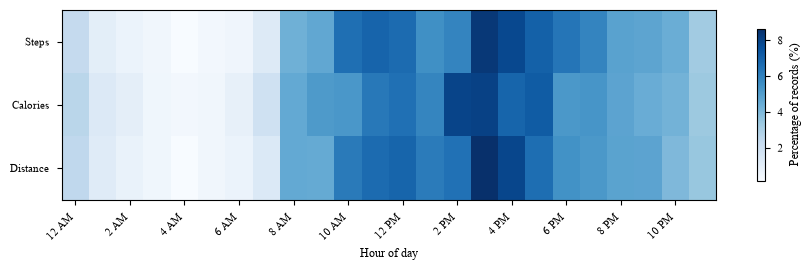

In [ ]:
#What proportion of each modality's records occurs during each hour of the day?
steps_pct = steps_hourly / steps_hourly.sum() * 100
calories_pct = calories_hourly / calories_hourly.sum() * 100
distance_pct = distance_hourly / distance_hourly.sum() * 100

fig, ax = plt.subplots(figsize=(9, 2.8))

matrix = np.vstack([
    steps_pct.values,
    calories_pct.values,
    distance_pct.values,
])

im = ax.imshow(
    matrix,
    aspect="auto",
    cmap="Blues"
)

ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["Steps", "Calories", "Distance"])

ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels(
    [hour_labels[h] for h in range(0, 24, 2)],
    rotation=45,
    ha="right"
)

ax.set_xlabel("Hour of day")

fig.colorbar(
    im,
    ax=ax,
    label="Percentage of records (%)",
    shrink=0.8
)

plt.tight_layout()
plt.show()

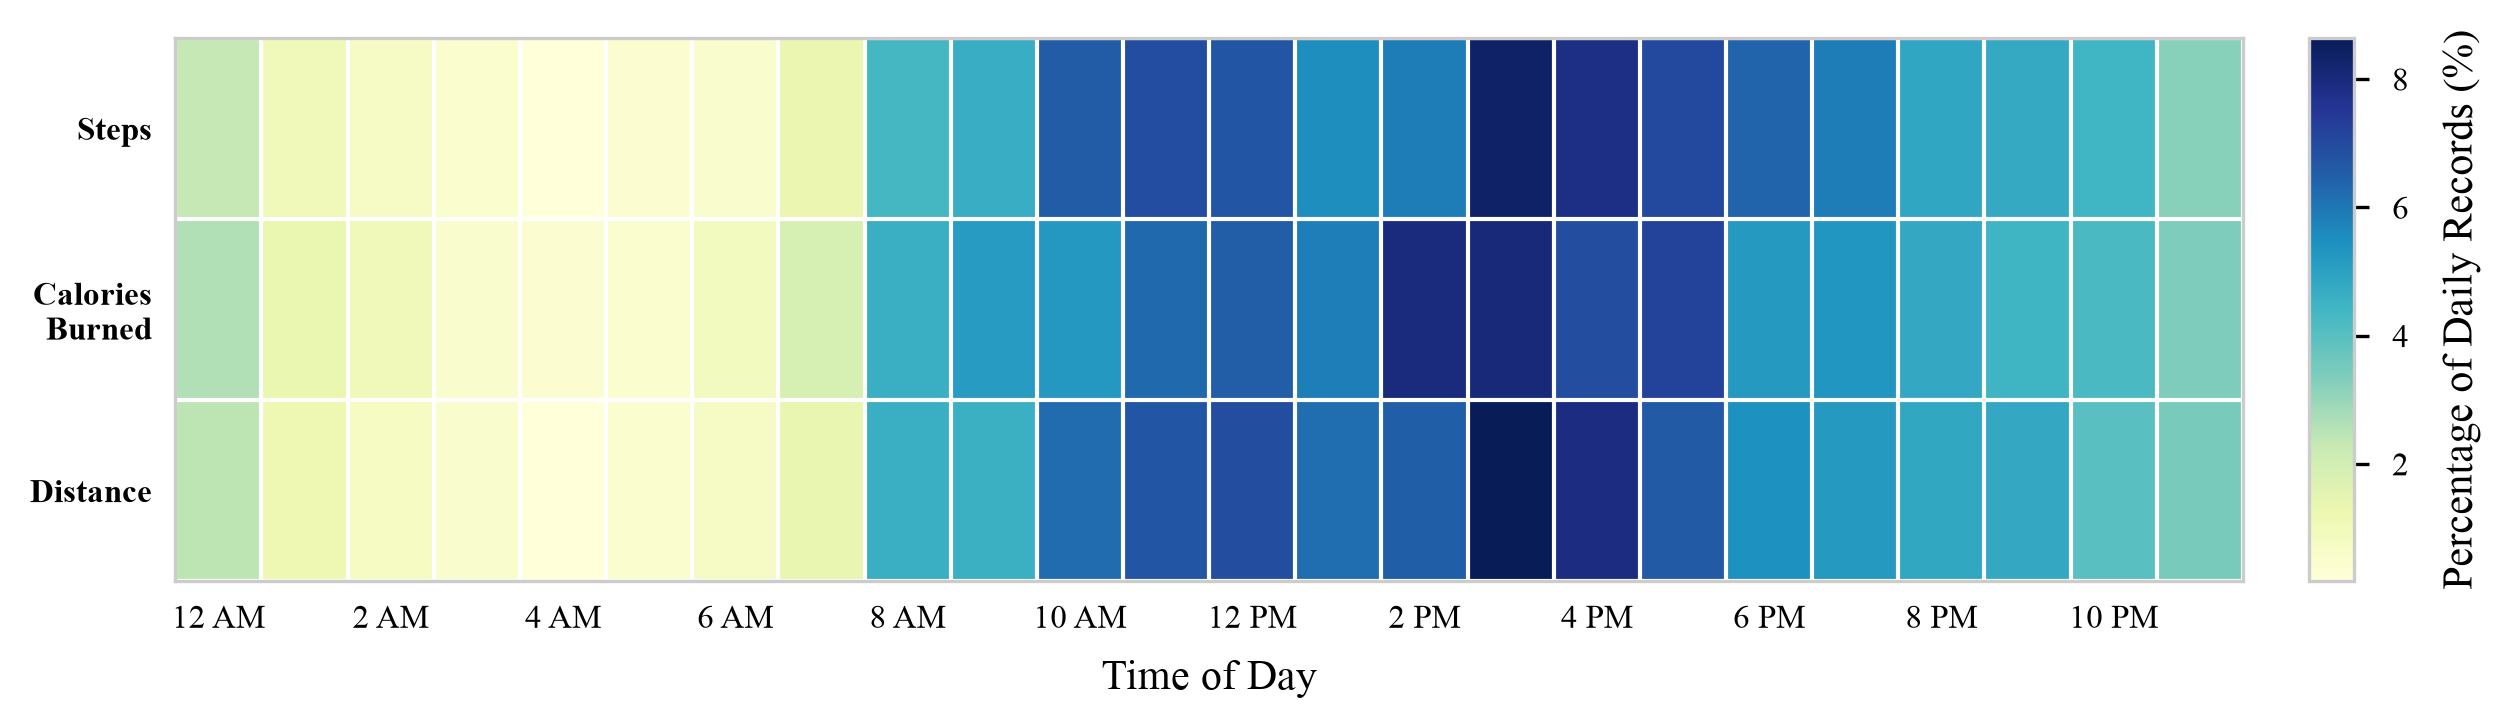

In [ ]:



plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.labelsize"] = 10

# Proportions
steps_pct = steps_hourly / steps_hourly.sum() * 100
calories_pct = calories_hourly / calories_hourly.sum() * 100
distance_pct = distance_hourly / distance_hourly.sum() * 100

matrix = np.vstack([
    steps_pct.values,
    calories_pct.values,
    distance_pct.values,
])

fig, ax = plt.subplots(figsize=(8.5, 2.5), dpi=300)

# YlGnBu Colormap
im = ax.imshow(
    matrix,
    aspect="auto",
    cmap="YlGnBu",
    interpolation="nearest"
)

# Y-axis
modalities = ["Steps", "Calories\nBurned", "Distance"]
ax.set_yticks(range(len(modalities)))
ax.set_yticklabels(modalities, fontweight="bold")

# X-axis (12-Hour AM/PM)
x_ticks = range(0, 24, 2)

def format_ampm(hour):
    if hour == 0:
        return "12 AM"
    elif hour == 12:
        return "12 PM"
    elif hour < 12:
        return f"{hour} AM"
    else:
        return f"{hour - 12} PM"

ax.set_xticks(x_ticks)
ax.set_xticklabels([format_ampm(h) for h in x_ticks], rotation=0, ha="center")
ax.set_xlabel("Time of Day", labelpad=6)

# Grid separation
ax.set_xticks(np.arange(-0.5, 24, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 3, 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(axis="both", which="both", length=0)

# Spines
for spine in ax.spines.values():
    spine.set_color("#cccccc")
    spine.set_linewidth(0.8)

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.03, aspect=12)
cbar.set_label("Percentage of Daily Records (%)", labelpad=8)
cbar.outline.set_color("#cccccc")
cbar.outline.set_linewidth(0.8)

#ax.set_title("Distribution of Recorded Activity Modalities", fontweight="bold", pad=10)

plt.tight_layout()
plt.show()

Steps at 3 PM = 6% means that 6% of all step records occurred during the 8 AM hour.

---------------------------------------------

## Survey distributions

## - 1) How does response participation change across the 28-day study?
## - 2) How does overall response rate change from week to week?

In [34]:
df_survey_raw = db.extract_from_database("survey_response")

# Remove duplicate survey responses
df_survey_raw = df_survey_raw.drop_duplicates(
    subset=["app_user_id", "survey_id", "timestamp"]
)

# Remove excluded users
df_survey_raw = remove_excluded_users(df_survey_raw)

# Convert timestamp to datetime
df_survey_raw["timestamp"] = pd.to_datetime(df_survey_raw["timestamp"])

In [35]:
df_survey_raw

,id,app_user_id,survey_id,timestamp,notification_start,client_submission_id
0,1,5,0,2025-11-15 10:17:54.641,2025-11-15 10:17:54.648,NaN
1,2,5,1,2025-11-15 17:52:03.295,2025-11-15 17:52:03.305,NaN
2,3,5,0,2025-11-16 10:34:25.655,2025-11-16 10:34:25.660,NaN
3,4,5,1,2025-11-16 17:03:13.659,2025-11-16 17:03:13.662,NaN
4,5,5,0,2025-11-17 10:59:22.663,2025-11-17 10:59:22.673,NaN
...,...,...,...,...,...,...
2169,2170,52,1,2026-09-06 18:41:14.290,2026-09-06 18:41:14.292,84941abb-8320-4913-845d-0b0c531f0403
2170,2171,52,1,2026-09-07 18:29:23.583,2026-09-07 18:29:23.585,6760b86a-e0cd-4aa0-a5e9-453ba0d5e374
2171,2172,52,0,2026-09-08 10:36:35.727,2026-09-08 10:36:35.728,5b29dc1a-60a4-4bb1-adc4-453dc6738191
2172,2173,52,1,2026-09-08 16:59:21.592,2026-09-08 16:59:21.594,0c8af8a3-f336-4d54-9b4b-3b3a8ca623c2


In [36]:
duplicates = df_survey_raw[
    df_survey_raw.duplicated(
        subset=["app_user_id", "survey_id", "timestamp"],
        keep=False
    )
]

print(duplicates)
print("Number of duplicate rows:", len(duplicates))

Empty DataFrame
Columns: [id, app_user_id, survey_id, timestamp, notification_start, client_submission_id]
Index: []
Number of duplicate rows: 0


In [37]:
print("Duplicate rows:", df_survey_raw.duplicated().sum())

Duplicate rows: 0


In [38]:
df_survey_raw = db.extract_from_database("survey_response")

print("Rows before removing duplicates:", len(df_survey_raw))

df_survey_raw = df_survey_raw.drop_duplicates(
    subset=["app_user_id", "survey_id", "timestamp"]
)

print("Rows after removing duplicates:", len(df_survey_raw))

df_survey_raw = remove_excluded_users(df_survey_raw)

df_survey_raw["timestamp"] = pd.to_datetime(df_survey_raw["timestamp"])

Rows before removing duplicates: 2174
Rows after removing duplicates: 2168


In [ ]:
#For each user, what is their earliest survey-response timestamp?     #only keep date
user_start = df_survey_raw.groupby("app_user_id")["timestamp"].min().dt.normalize()
#output user id and earliest survey response date

df_survey_raw["study_day"] = (
    # date that a survey happens-date of first survey + 1
    df_survey_raw["timestamp"].dt.normalize() - df_survey_raw["app_user_id"].map(user_start)).dt.days + 1

STUDY_LENGTH_DAYS = 28

# Keep only morning (0.0) and afternoon (1.0) EMA responses; survey_id == 2 is the weekly survey (pHQ9)
ema = df_survey_raw[df_survey_raw["survey_id"].isin([0.0, 1.0])].copy()
ema = ema[ema["study_day"].between(1, STUDY_LENGTH_DAYS)]

# Keep only ONE response per user, per study day, per EMA type 
# (if we have duplicate entries for a survey in a given study day, we keep first one)
ema = ema.drop_duplicates(
    subset=["app_user_id", "study_day", "survey_id"],
    keep="first"
)

#morning (0.0) and afternoon (1.0) 
morning = ema[ema["survey_id"] == 0.0]
afternoon = ema[ema["survey_id"] == 1.0]

In [40]:
df_survey_raw

,id,app_user_id,survey_id,timestamp,notification_start,client_submission_id,study_day
0,1,5,0,2025-11-15 10:17:54.641,2025-11-15 10:17:54.648,NaN,1
1,2,5,1,2025-11-15 17:52:03.295,2025-11-15 17:52:03.305,NaN,1
2,3,5,0,2025-11-16 10:34:25.655,2025-11-16 10:34:25.660,NaN,2
3,4,5,1,2025-11-16 17:03:13.659,2025-11-16 17:03:13.662,NaN,2
4,5,5,0,2025-11-17 10:59:22.663,2025-11-17 10:59:22.673,NaN,3
...,...,...,...,...,...,...,...
2169,2170,52,1,2026-09-06 18:41:14.290,2026-09-06 18:41:14.292,84941abb-8320-4913-845d-0b0c531f0403,5
2170,2171,52,1,2026-09-07 18:29:23.583,2026-09-07 18:29:23.585,6760b86a-e0cd-4aa0-a5e9-453ba0d5e374,6
2171,2172,52,0,2026-09-08 10:36:35.727,2026-09-08 10:36:35.728,5b29dc1a-60a4-4bb1-adc4-453dc6738191,7
2172,2173,52,1,2026-09-08 16:59:21.592,2026-09-08 16:59:21.594,0c8af8a3-f336-4d54-9b4b-3b3a8ca623c2,7


In [41]:
#for app_user_id =5
df_survey_raw[df_survey_raw["app_user_id"]==5]

,id,app_user_id,survey_id,timestamp,notification_start,client_submission_id,study_day
0,1,5,0,2025-11-15 10:17:54.641,2025-11-15 10:17:54.648,NaN,1
1,2,5,1,2025-11-15 17:52:03.295,2025-11-15 17:52:03.305,NaN,1
2,3,5,0,2025-11-16 10:34:25.655,2025-11-16 10:34:25.660,NaN,2
3,4,5,1,2025-11-16 17:03:13.659,2025-11-16 17:03:13.662,NaN,2
4,5,5,0,2025-11-17 10:59:22.663,2025-11-17 10:59:22.673,NaN,3
5,6,5,1,2025-11-17 18:29:26.732,2025-11-17 18:29:26.741,NaN,3
6,7,5,0,2025-11-18 08:56:49.320,2025-11-18 08:56:49.328,NaN,4
17,18,5,1,2025-11-18 17:55:01.458,2025-11-18 17:55:01.467,NaN,4
26,27,5,0,2025-11-19 11:04:46.601,2025-11-19 11:04:46.607,NaN,5
38,39,5,1,2025-11-19 19:21:10.985,2025-11-19 19:21:10.993,NaN,5


In [ ]:
#for app_user_id =11 - has duplicates - check if duplicates are removed
ema[ema["app_user_id"]==11]

,id,app_user_id,survey_id,timestamp,notification_start,client_submission_id,study_day
19,20,11,0,2025-11-19 09:03:36.463,2025-11-19 09:03:36.478,NaN,1
30,31,11,1,2025-11-19 15:20:51.803,2025-11-19 15:20:51.825,NaN,1
43,44,11,0,2025-11-20 09:04:06.237,2025-11-20 09:04:06.258,NaN,2
55,56,11,1,2025-11-20 16:21:28.341,2025-11-20 16:21:28.354,NaN,2
59,60,11,0,2025-11-21 09:23:52.587,2025-11-21 09:23:52.600,NaN,3
75,76,11,1,2025-11-21 16:34:41.883,2025-11-21 16:34:41.903,NaN,3
85,86,11,0,2025-11-22 10:36:12.719,2025-11-22 10:36:12.741,NaN,4
89,90,11,1,2025-11-22 15:41:31.677,2025-11-22 15:41:31.695,NaN,4
99,100,11,0,2025-11-23 09:52:41.868,2025-11-23 09:52:41.888,NaN,5
111,112,11,1,2025-11-23 16:03:54.223,2025-11-23 16:03:54.233,NaN,5


In [43]:
ema

,id,app_user_id,survey_id,timestamp,notification_start,client_submission_id,study_day
0,1,5,0,2025-11-15 10:17:54.641,2025-11-15 10:17:54.648,NaN,1
1,2,5,1,2025-11-15 17:52:03.295,2025-11-15 17:52:03.305,NaN,1
2,3,5,0,2025-11-16 10:34:25.655,2025-11-16 10:34:25.660,NaN,2
3,4,5,1,2025-11-16 17:03:13.659,2025-11-16 17:03:13.662,NaN,2
4,5,5,0,2025-11-17 10:59:22.663,2025-11-17 10:59:22.673,NaN,3
...,...,...,...,...,...,...,...
2169,2170,52,1,2026-09-06 18:41:14.290,2026-09-06 18:41:14.292,84941abb-8320-4913-845d-0b0c531f0403,5
2170,2171,52,1,2026-09-07 18:29:23.583,2026-09-07 18:29:23.585,6760b86a-e0cd-4aa0-a5e9-453ba0d5e374,6
2171,2172,52,0,2026-09-08 10:36:35.727,2026-09-08 10:36:35.728,5b29dc1a-60a4-4bb1-adc4-453dc6738191,7
2172,2173,52,1,2026-09-08 16:59:21.592,2026-09-08 16:59:21.594,0c8af8a3-f336-4d54-9b4b-3b3a8ca623c2,7


In [44]:
df_survey_raw

,id,app_user_id,survey_id,timestamp,notification_start,client_submission_id,study_day
0,1,5,0,2025-11-15 10:17:54.641,2025-11-15 10:17:54.648,NaN,1
1,2,5,1,2025-11-15 17:52:03.295,2025-11-15 17:52:03.305,NaN,1
2,3,5,0,2025-11-16 10:34:25.655,2025-11-16 10:34:25.660,NaN,2
3,4,5,1,2025-11-16 17:03:13.659,2025-11-16 17:03:13.662,NaN,2
4,5,5,0,2025-11-17 10:59:22.663,2025-11-17 10:59:22.673,NaN,3
...,...,...,...,...,...,...,...
2169,2170,52,1,2026-09-06 18:41:14.290,2026-09-06 18:41:14.292,84941abb-8320-4913-845d-0b0c531f0403,5
2170,2171,52,1,2026-09-07 18:29:23.583,2026-09-07 18:29:23.585,6760b86a-e0cd-4aa0-a5e9-453ba0d5e374,6
2171,2172,52,0,2026-09-08 10:36:35.727,2026-09-08 10:36:35.728,5b29dc1a-60a4-4bb1-adc4-453dc6738191,7
2172,2173,52,1,2026-09-08 16:59:21.592,2026-09-08 16:59:21.594,0c8af8a3-f336-4d54-9b4b-3b3a8ca623c2,7


In [45]:
user_start

app_user_id
5    2025-11-15
6    2025-11-18
7    2025-11-18
8    2025-11-18
9    2025-11-18
11   2025-11-19
14   2025-11-19
15   2025-11-19
16   2025-11-19
17   2025-11-21
18   2025-11-26
19   2025-12-03
20   2025-12-04
23   2026-03-24
24   2026-03-25
25   2026-03-26
26   2026-03-26
27   2026-03-27
28   2026-03-28
29   2026-03-28
30   2026-04-01
31   2026-04-02
32   2026-04-04
33   2026-04-10
34   2026-04-10
35   2026-04-10
36   2026-04-11
37   2026-04-14
38   2026-04-15
39   2026-04-16
40   2026-04-16
41   2026-04-16
42   2026-04-16
45   2026-04-25
46   2026-05-02
47   2026-05-02
48   2026-05-07
49   2026-06-09
50   2026-06-19
52   2026-09-02
Name: timestamp, dtype: datetime64[us]

In [46]:
morning

,id,app_user_id,survey_id,timestamp,notification_start,client_submission_id,study_day
0,1,5,0,2025-11-15 10:17:54.641,2025-11-15 10:17:54.648,NaN,1
2,3,5,0,2025-11-16 10:34:25.655,2025-11-16 10:34:25.660,NaN,2
4,5,5,0,2025-11-17 10:59:22.663,2025-11-17 10:59:22.673,NaN,3
6,7,5,0,2025-11-18 08:56:49.320,2025-11-18 08:56:49.328,NaN,4
7,8,9,0,2025-11-18 09:31:44.097,2025-11-18 09:31:44.107,NaN,1
...,...,...,...,...,...,...,...
2163,2164,52,0,2026-09-03 12:50:55.357,2026-09-03 12:50:55.359,76603502-1883-4308-90bf-71bbaa83b7fd,2
2165,2166,52,0,2026-09-04 10:57:34.257,2026-09-04 10:57:34.258,bf3ef211-5a10-4870-9145-9016648942d1,3
2167,2168,52,0,2026-09-05 11:55:34.213,2026-09-05 11:55:34.217,2cc932a1-91e1-4ea3-9b83-5c784c96b83f,4
2171,2172,52,0,2026-09-08 10:36:35.727,2026-09-08 10:36:35.728,5b29dc1a-60a4-4bb1-adc4-453dc6738191,7


In [47]:
afternoon

,id,app_user_id,survey_id,timestamp,notification_start,client_submission_id,study_day
1,2,5,1,2025-11-15 17:52:03.295,2025-11-15 17:52:03.305,NaN,1
3,4,5,1,2025-11-16 17:03:13.659,2025-11-16 17:03:13.662,NaN,2
5,6,5,1,2025-11-17 18:29:26.732,2025-11-17 18:29:26.741,NaN,3
13,14,8,1,2025-11-18 15:11:53.050,2025-11-18 15:11:53.069,NaN,1
14,15,7,1,2025-11-18 15:26:03.838,2025-11-18 15:26:03.843,NaN,1
...,...,...,...,...,...,...,...
2166,2167,52,1,2026-09-04 17:07:25.505,2026-09-04 17:07:25.508,89741a2e-5148-4d82-8787-59310f012cb5,3
2168,2169,52,1,2026-09-05 16:10:32.309,2026-09-05 16:10:32.317,13f7794d-9042-407f-a8f1-93a4c65ace30,4
2169,2170,52,1,2026-09-06 18:41:14.290,2026-09-06 18:41:14.292,84941abb-8320-4913-845d-0b0c531f0403,5
2170,2171,52,1,2026-09-07 18:29:23.583,2026-09-07 18:29:23.585,6760b86a-e0cd-4aa0-a5e9-453ba0d5e374,6


## raw values plot

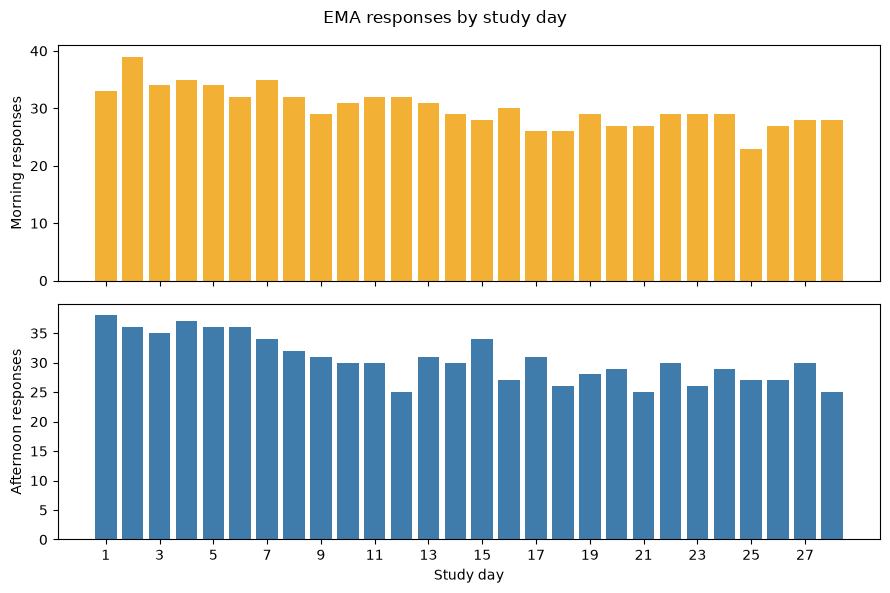

In [48]:
survey_colors = {"morning": "#f2b134", "afternoon": "#3f7cac"}

# How many morning and afternoon responses did we receive on each study day?
morning_by_day = (
    morning.groupby("study_day")
    .size()
    .reindex(range(1, STUDY_LENGTH_DAYS + 1), fill_value=0)
)

afternoon_by_day = (
    afternoon.groupby("study_day")
    .size()
    .reindex(range(1, STUDY_LENGTH_DAYS + 1), fill_value=0)
)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

for ax, (name, counts) in zip(
    axes,
    [("morning", morning_by_day), ("afternoon", afternoon_by_day)]
):
    ax.bar(counts.index, counts.values, color=survey_colors[name])
    ax.set_ylabel(f"{name.capitalize()} responses")

axes[-1].set_xlabel("Study day")
axes[-1].set_xticks(range(1, STUDY_LENGTH_DAYS + 1, 2))

fig.suptitle("EMA responses by study day")
plt.tight_layout()
plt.show()

In [49]:
morning_by_day

study_day
1     33
2     39
3     34
4     35
5     34
6     32
7     35
8     32
9     29
10    31
11    32
12    32
13    31
14    29
15    28
16    30
17    26
18    26
19    29
20    27
21    27
22    29
23    29
24    29
25    23
26    27
27    28
28    28
dtype: int64

In [50]:
morning_day1_ids = set(
    morning.loc[morning["study_day"] == 1, "app_user_id"]
)

print("Morning responses on Day 1:", len(morning_day1_ids))

Morning responses on Day 1: 33


In [51]:
expected_ids = set(df_survey_raw["app_user_id"].unique())

print("Expected participants:", len(expected_ids))

Expected participants: 40


In [52]:
missing_day1 = expected_ids - morning_day1_ids

print("Missing morning response on Day 1:", len(missing_day1))
print(missing_day1)

Missing morning response on Day 1: 7
{np.int64(32), np.int64(48), np.int64(50), np.int64(52), np.int64(27), np.int64(28), np.int64(30)}


In [53]:
total_morning = len(morning)
total_afternoon = len(afternoon)

print("Total morning responses:", total_morning)
print("Total afternoon responses:", total_afternoon)

Total morning responses: 844
Total afternoon responses: 855


## Percentage

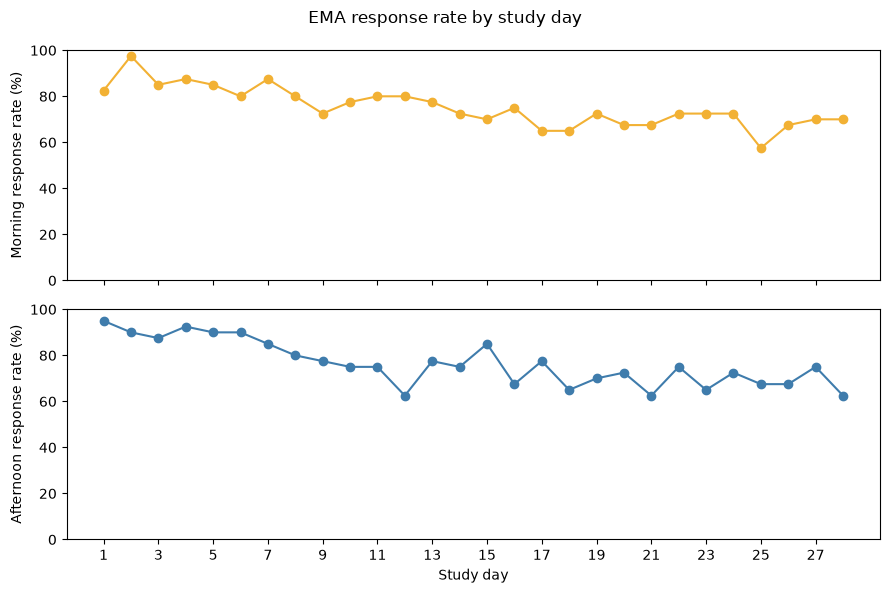

In [ ]:
survey_colors = {
    "morning": "#f2b134",
    "afternoon": "#3f7cac"
}

# Number of users
n_users = df_survey_raw["app_user_id"].nunique()

# Responses received each day
morning_by_day = (
    morning.groupby("study_day")
    .size()
    .reindex(range(1, STUDY_LENGTH_DAYS + 1), fill_value=0)
)

afternoon_by_day = (
    afternoon.groupby("study_day")
    .size()
    .reindex(range(1, STUDY_LENGTH_DAYS + 1), fill_value=0)
)

# Convert responses to percentage of expected responses
#morning responses/# of users, afternoon responses/# of users * 100
morning_percent = (morning_by_day / n_users) * 100
afternoon_percent = (afternoon_by_day / n_users) * 100

# two plots
fig, axes = plt.subplots(
    2, 1,
    figsize=(9, 6),
    sharex=True
)

for ax, (name, percentages) in zip(
    axes,
    [
        ("morning", morning_percent),
        ("afternoon", afternoon_percent)
    ]
):
    
    ax.plot(
        percentages.index,
        percentages.values,
        marker="o",
        linewidth=1.5,
        color=survey_colors[name]
    )
    
    ax.set_ylabel(f"{name.capitalize()} response rate (%)")
    ax.set_ylim(0, 100)

# X-axis
axes[-1].set_xlabel("Study day")
axes[-1].set_xticks(
    range(1, STUDY_LENGTH_DAYS + 1, 2)
)

fig.suptitle("EMA response rate by study day")

plt.tight_layout()
plt.show()

In [55]:
n_users = df_survey_raw["app_user_id"].nunique()
print(n_users)

users = df_survey_raw["app_user_id"].unique()
print(users)


40
[ 5  9  7  8  6 11 14 15 16 17 18 19 20 23 24 25 26 27 29 28 30 31 32 35
 33 34 36 37 38 39 41 42 40 45 47 46 48 49 50 52]


## percentage - bar chart

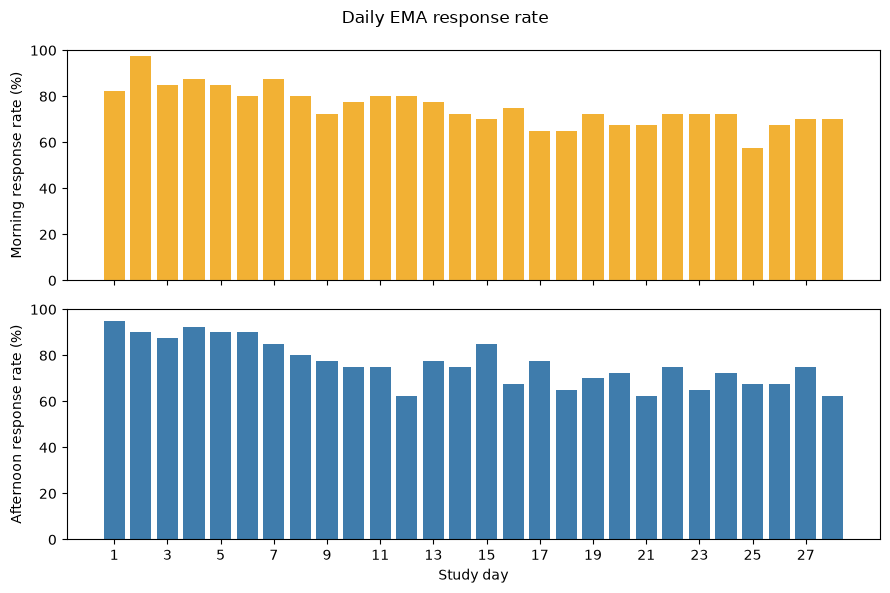

In [56]:
survey_colors = {"morning": "#f2b134", "afternoon": "#3f7cac"}

# How many morning and afternoon responses did we receive on each study day?
morning_by_day = (
    morning.groupby("study_day")
    .size()
    .reindex(range(1, STUDY_LENGTH_DAYS + 1), fill_value=0)
)

afternoon_by_day = (
    afternoon.groupby("study_day")
    .size()
    .reindex(range(1, STUDY_LENGTH_DAYS + 1), fill_value=0)
)

# Total number of users
n_users = df_survey_raw["app_user_id"].nunique()

# Convert response counts to percentage of users
morning_pct = (morning_by_day / n_users) * 100
afternoon_pct = (afternoon_by_day / n_users) * 100

# Create two plots
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

for ax, (name, percentages) in zip(
    axes,
    [("morning", morning_pct), ("afternoon", afternoon_pct)]
):
    
    ax.bar(
        percentages.index,
        percentages.values,
        color=survey_colors[name]
    )
    
    ax.set_ylabel(f"{name.capitalize()} response rate (%)")
    ax.set_ylim(0, 100)

axes[-1].set_xlabel("Study day")
axes[-1].set_xticks(range(1, STUDY_LENGTH_DAYS + 1, 2))

fig.suptitle("Daily EMA response rate")
plt.tight_layout()
plt.show()

In [87]:
n_users

40

## percentage, one graph

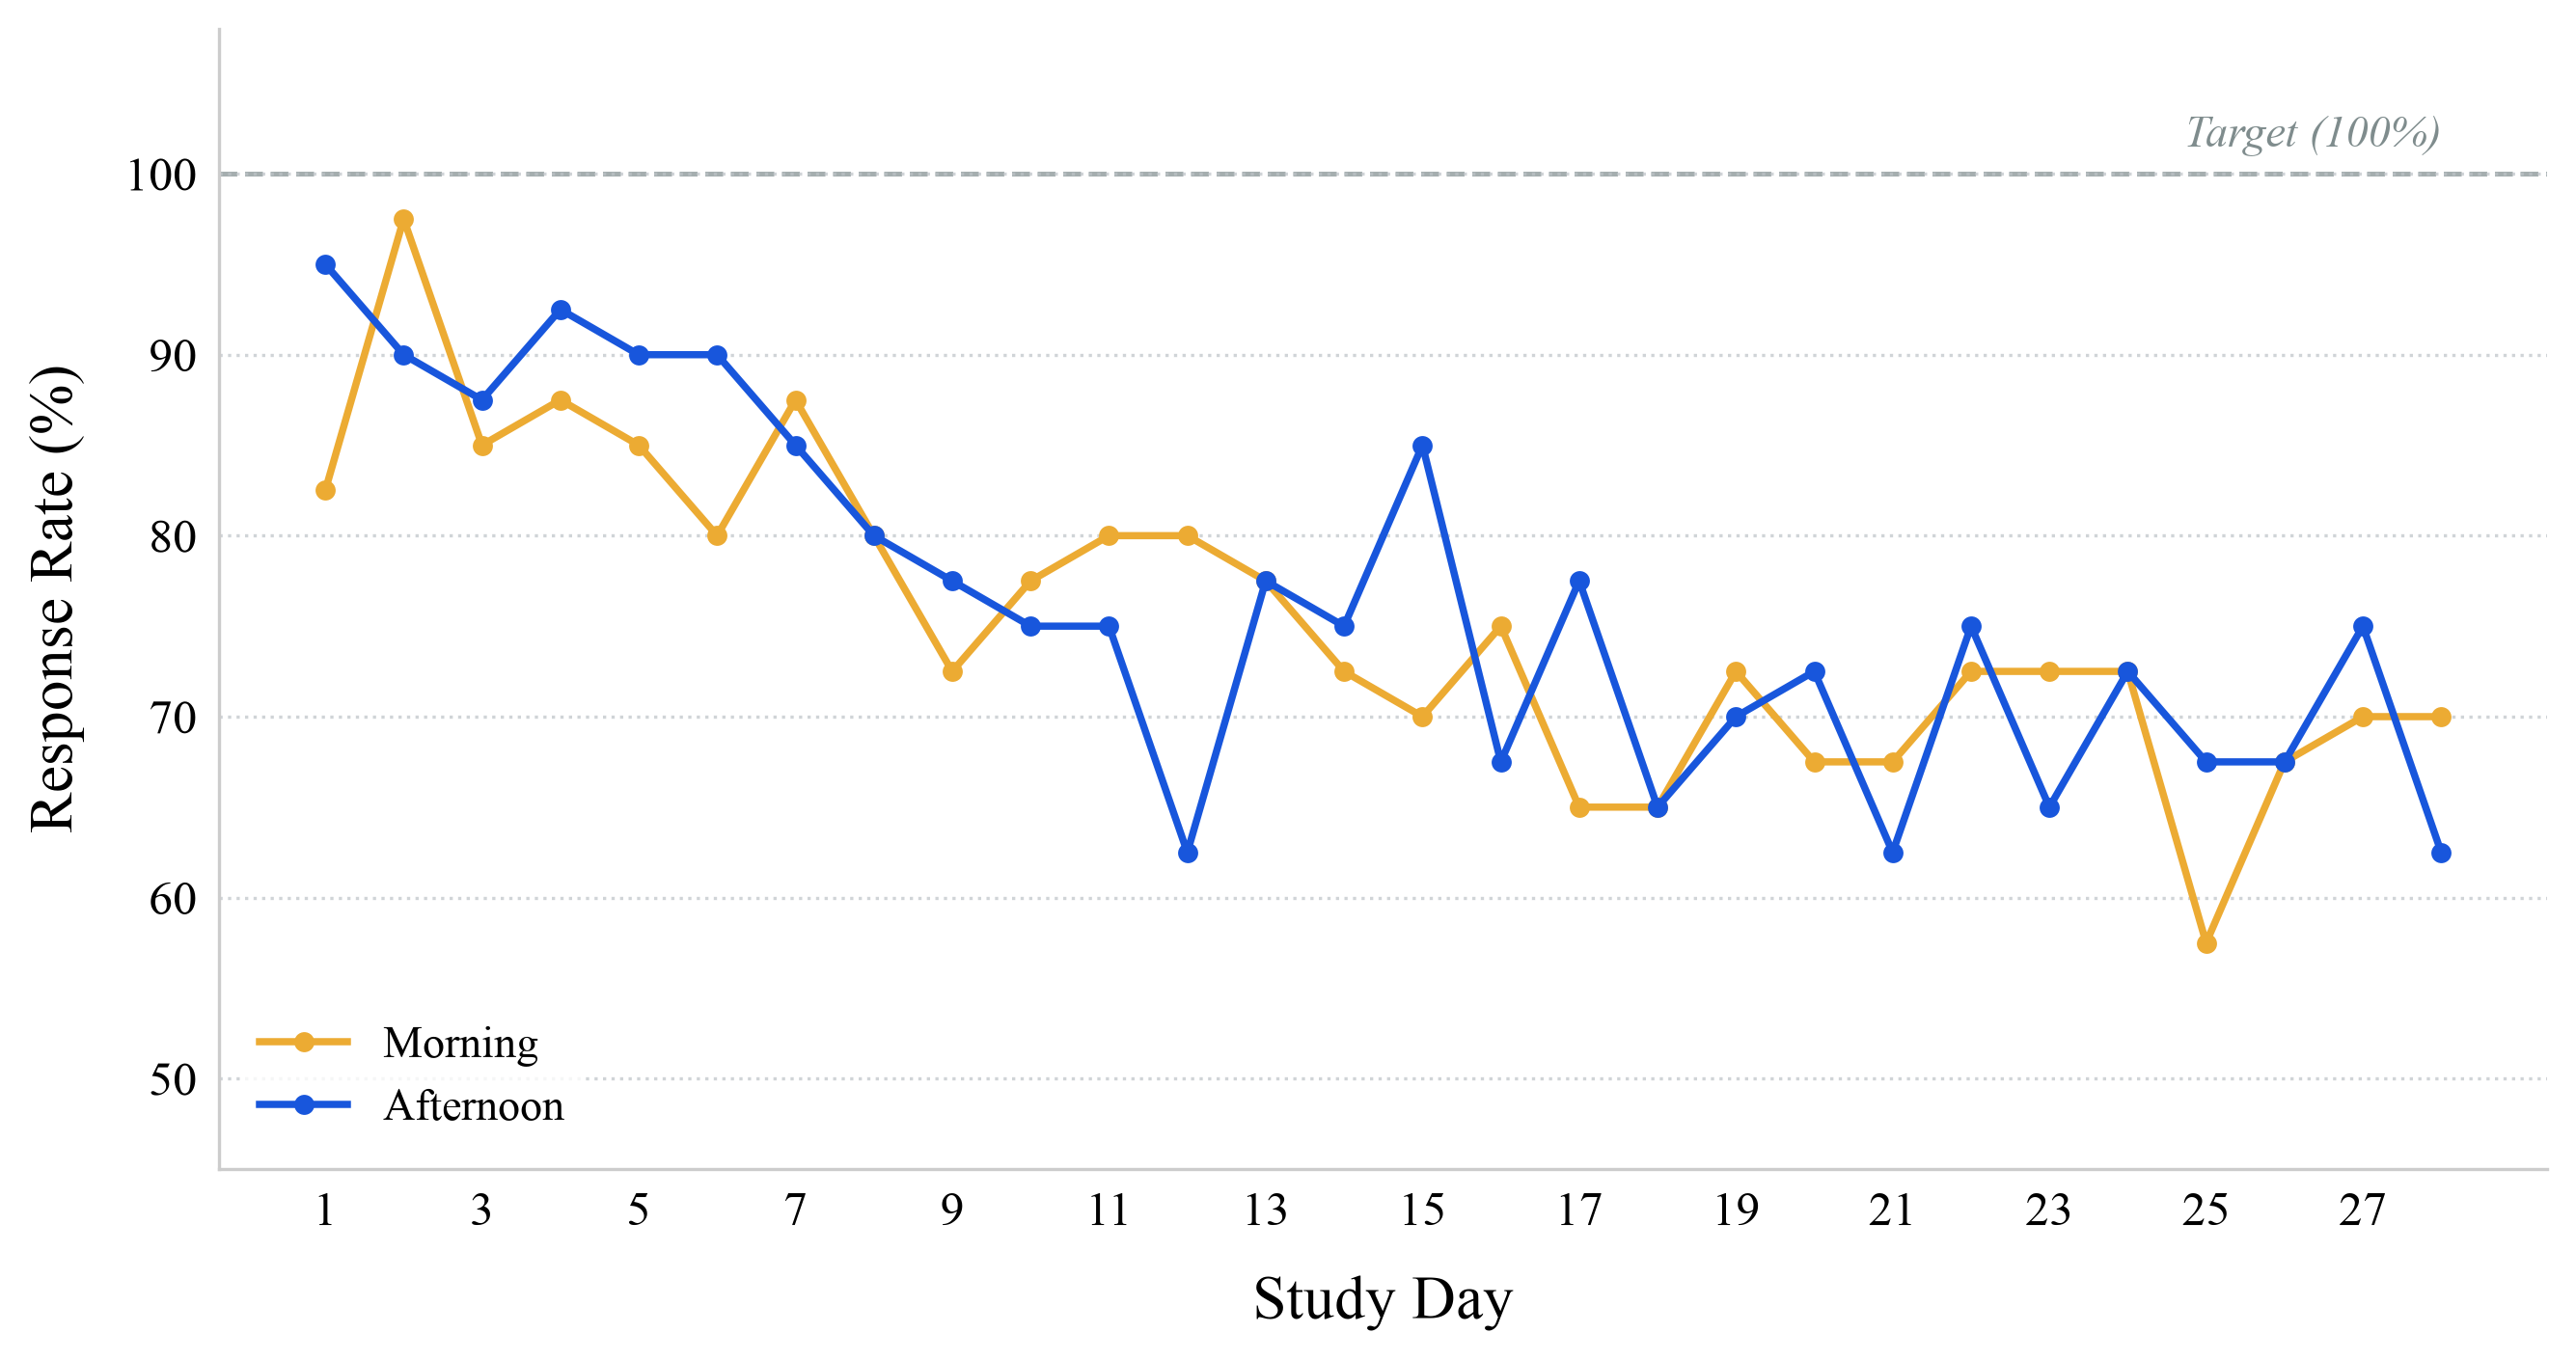

In [ ]:

plt.style.use("seaborn-v0_8-paper")
plt.rcParams["font.family"] = "Times New Roman"
fig, ax = plt.subplots(figsize=(9, 4.8), dpi=300)


colors = {
    "Morning": "#ecab33",   
    "Afternoon": "#1856dc" 
}

data = {
    "Morning": morning_percent,
    "Afternoon": afternoon_percent
}

# daily lines 
for label, s in data.items():
    ax.plot(
        s.index, 
        s.values, 
        marker="o", 
        markersize=5, 
        linewidth=1.8, 
        color=colors[label], 
        label=label
    )

# 100% Target Reference Line
ax.axhline(100, linestyle="--", linewidth=1.2, color="#7f8c8d", alpha=0.7, zorder=1)
ax.text(
    STUDY_LENGTH_DAYS, 101.5, " Target (100%)", 
    color="#7f8c8d", fontsize=11, fontstyle="italic", ha="right"
)

# Axis & Title
ax.set_xlabel("Study Day", fontsize=15, labelpad=10)
ax.set_ylabel("Response Rate (%)", fontsize=15, labelpad=10)

ax.set_ylim(45, 108)
ax.set_yticks(range(50, 101, 10))
ax.set_xticks(range(1, STUDY_LENGTH_DAYS + 1, 2 if STUDY_LENGTH_DAYS <= 30 else 5))


ax.tick_params(axis="both", which="major", labelsize=12, length=0)

# Legend 
ax.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=11, loc="lower left")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#cccccc")
    ax.spines[spine].set_linewidth(0.8)

ax.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.7, color="#bdc3c7")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Calculate Morning stats
morning_mean = morning_percent.mean()
morning_std = morning_percent.std()

# Calculate Afternoon stats
afternoon_mean = afternoon_percent.mean()
afternoon_std = afternoon_percent.std()

# Overall minimum compliance across both modalities
overall_min = min(morning_percent.min(), afternoon_percent.min())


print(
    f"Morning response rates averaged {morning_mean:.1f}% (± {morning_std:.1f}%), "
    f"while afternoon response rates averaged {afternoon_mean:.1f}% (± {afternoon_std:.1f}%). "
    f"Overall, compliance remained above {overall_min:.1f}% throughout the duration "
    f"of the monitoring protocol."
)

Morning response rates averaged 75.4% (± 8.5%), while afternoon response rates averaged 76.3% (± 9.8%). Overall, compliance remained above 57.5% throughout the duration of the monitoring protocol.


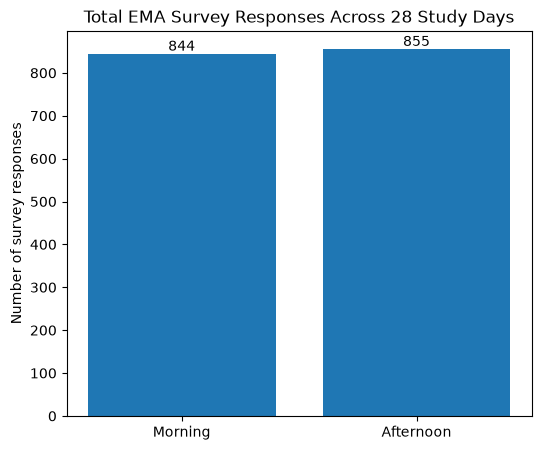

In [57]:
import matplotlib.pyplot as plt

totals = {
    "Morning": total_morning,
    "Afternoon": total_afternoon
}

plt.figure(figsize=(6, 5))

bars = plt.bar(totals.keys(), totals.values())

plt.ylabel("Number of survey responses")
plt.title("Total EMA Survey Responses Across 28 Study Days")

# Add numbers on top of bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom"
    )

plt.show()

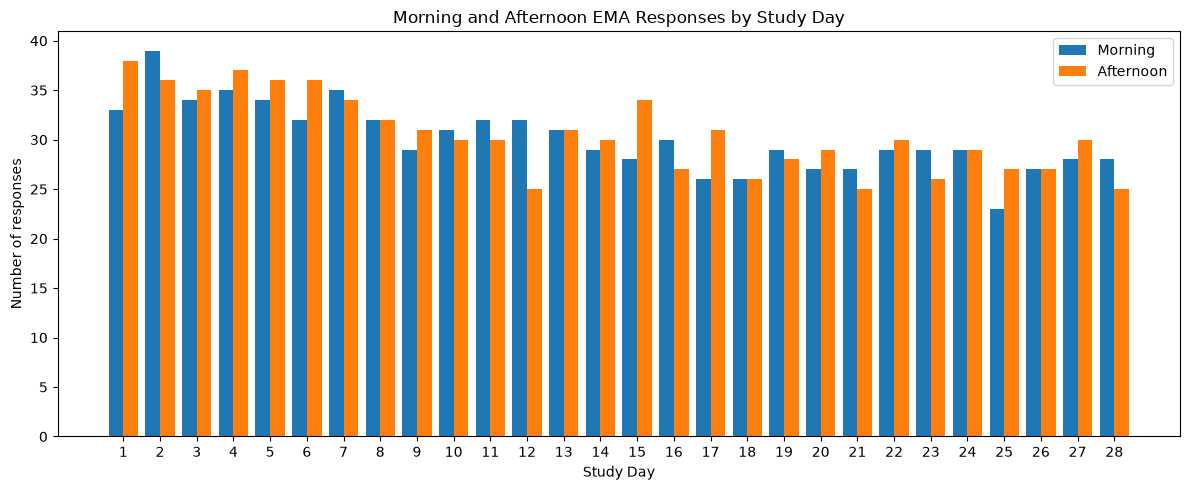

In [58]:
days = range(1, 29)

plt.figure(figsize=(12, 5))

width = 0.4

plt.bar(
    [d - width/2 for d in days],
    morning_by_day.values,
    width=width,
    label="Morning"
)

plt.bar(
    [d + width/2 for d in days],
    afternoon_by_day.values,
    width=width,
    label="Afternoon"
)

plt.xlabel("Study Day")
plt.ylabel("Number of responses")
plt.title("Morning and Afternoon EMA Responses by Study Day")
plt.xticks(range(1, 29))
plt.legend()

plt.tight_layout()
plt.show()

In [60]:
# responses per user on Day 1
day_1_counts = (
    afternoon[afternoon["study_day"] == 1]
    .groupby("app_user_id")
    .size()
)

#filter to users who submitted more than once
duplicates_day_1 = day_1_counts[day_1_counts > 1]

print(f"Total Day 1 Afternoon Responses: {len(afternoon[afternoon['study_day'] == 1])}")
print(f"Total Enrolled Users (Denominator): {n_users}")
print(f"\nUsers with duplicate submissions on Day 1:\n{duplicates_day_1}")

Total Day 1 Afternoon Responses: 38
Total Enrolled Users (Denominator): 40

Users with duplicate submissions on Day 1:
Series([], dtype: int64)


## weekly distribution

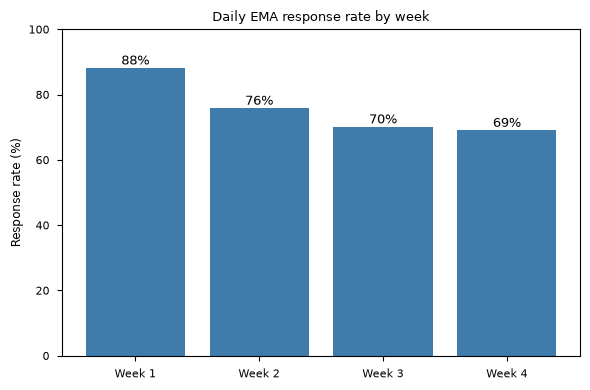

In [61]:
WEEK_BINS = [1, 8, 15, 22, 29]  # day ranges: 1-7, 8-14, 15-21, 22-28
WEEK_LABELS = ["Week 1", "Week 2", "Week 3", "Week 4"]

ema = ema.copy()
#use boundried defined earlier 
#1 ≤ day < 8 → Week 1
#8 ≤ day < 15 → Week 2
#15 ≤ day < 22 → Week 3
#22 ≤ day < 29 → Week 4
ema["week"] = pd.cut(ema["study_day"], bins=WEEK_BINS, right=False, labels=WEEK_LABELS)

n_users = df_survey_raw["app_user_id"].nunique()
expected_per_week = n_users * 7 * 2  # 7 days x 2 surveys/day x all enrolled users, full 28-day assumption

#This counts the actual survey-response rows in each week.

observed_per_week = ema.groupby("week", observed=True).size().reindex(WEEK_LABELS, fill_value=0)
response_rate = observed_per_week / expected_per_week * 100
                                      #41participants*7 days per week*2 daily EMA=574 expected response per week


fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(WEEK_LABELS, response_rate.values, color="#3f7cac")
ax.set_ylabel("Response rate (%)")
ax.set_title("Daily EMA response rate by week")
ax.set_ylim(0, 100)
for i, v in enumerate(response_rate.values):
    ax.text(i, v + 1, f"{v:.0f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

In [62]:
# Compare observed vs expected EMA responses in Week 1

n_users = df_survey_raw["app_user_id"].nunique()
#check the list of the app_user_ids of participants:
users=df_survey_raw["app_user_id"].unique()

# Actual EMA responses received in Week 1
week1_observed = (ema["week"] == "Week 1").sum()

# Expected responses under the assumption that all participants
# completed 2 EMAs per day for all 7 days
week1_expected = n_users * 7 * 2




print("Number of participants:", n_users)
print("list of participants:", users)

print("Week 1 observed EMA responses:", week1_observed)
print("Week 1 expected EMA responses:", week1_expected)
print(
    "Week 1 response rate:",
    f"{week1_observed / week1_expected * 100:.1f}%"
)

Number of participants: 40
list of participants: [ 5  9  7  8  6 11 14 15 16 17 18 19 20 23 24 25 26 27 29 28 30 31 32 35
 33 34 36 37 38 39 41 42 40 45 47 46 48 49 50 52]
Week 1 observed EMA responses: 494
Week 1 expected EMA responses: 560
Week 1 response rate: 88.2%


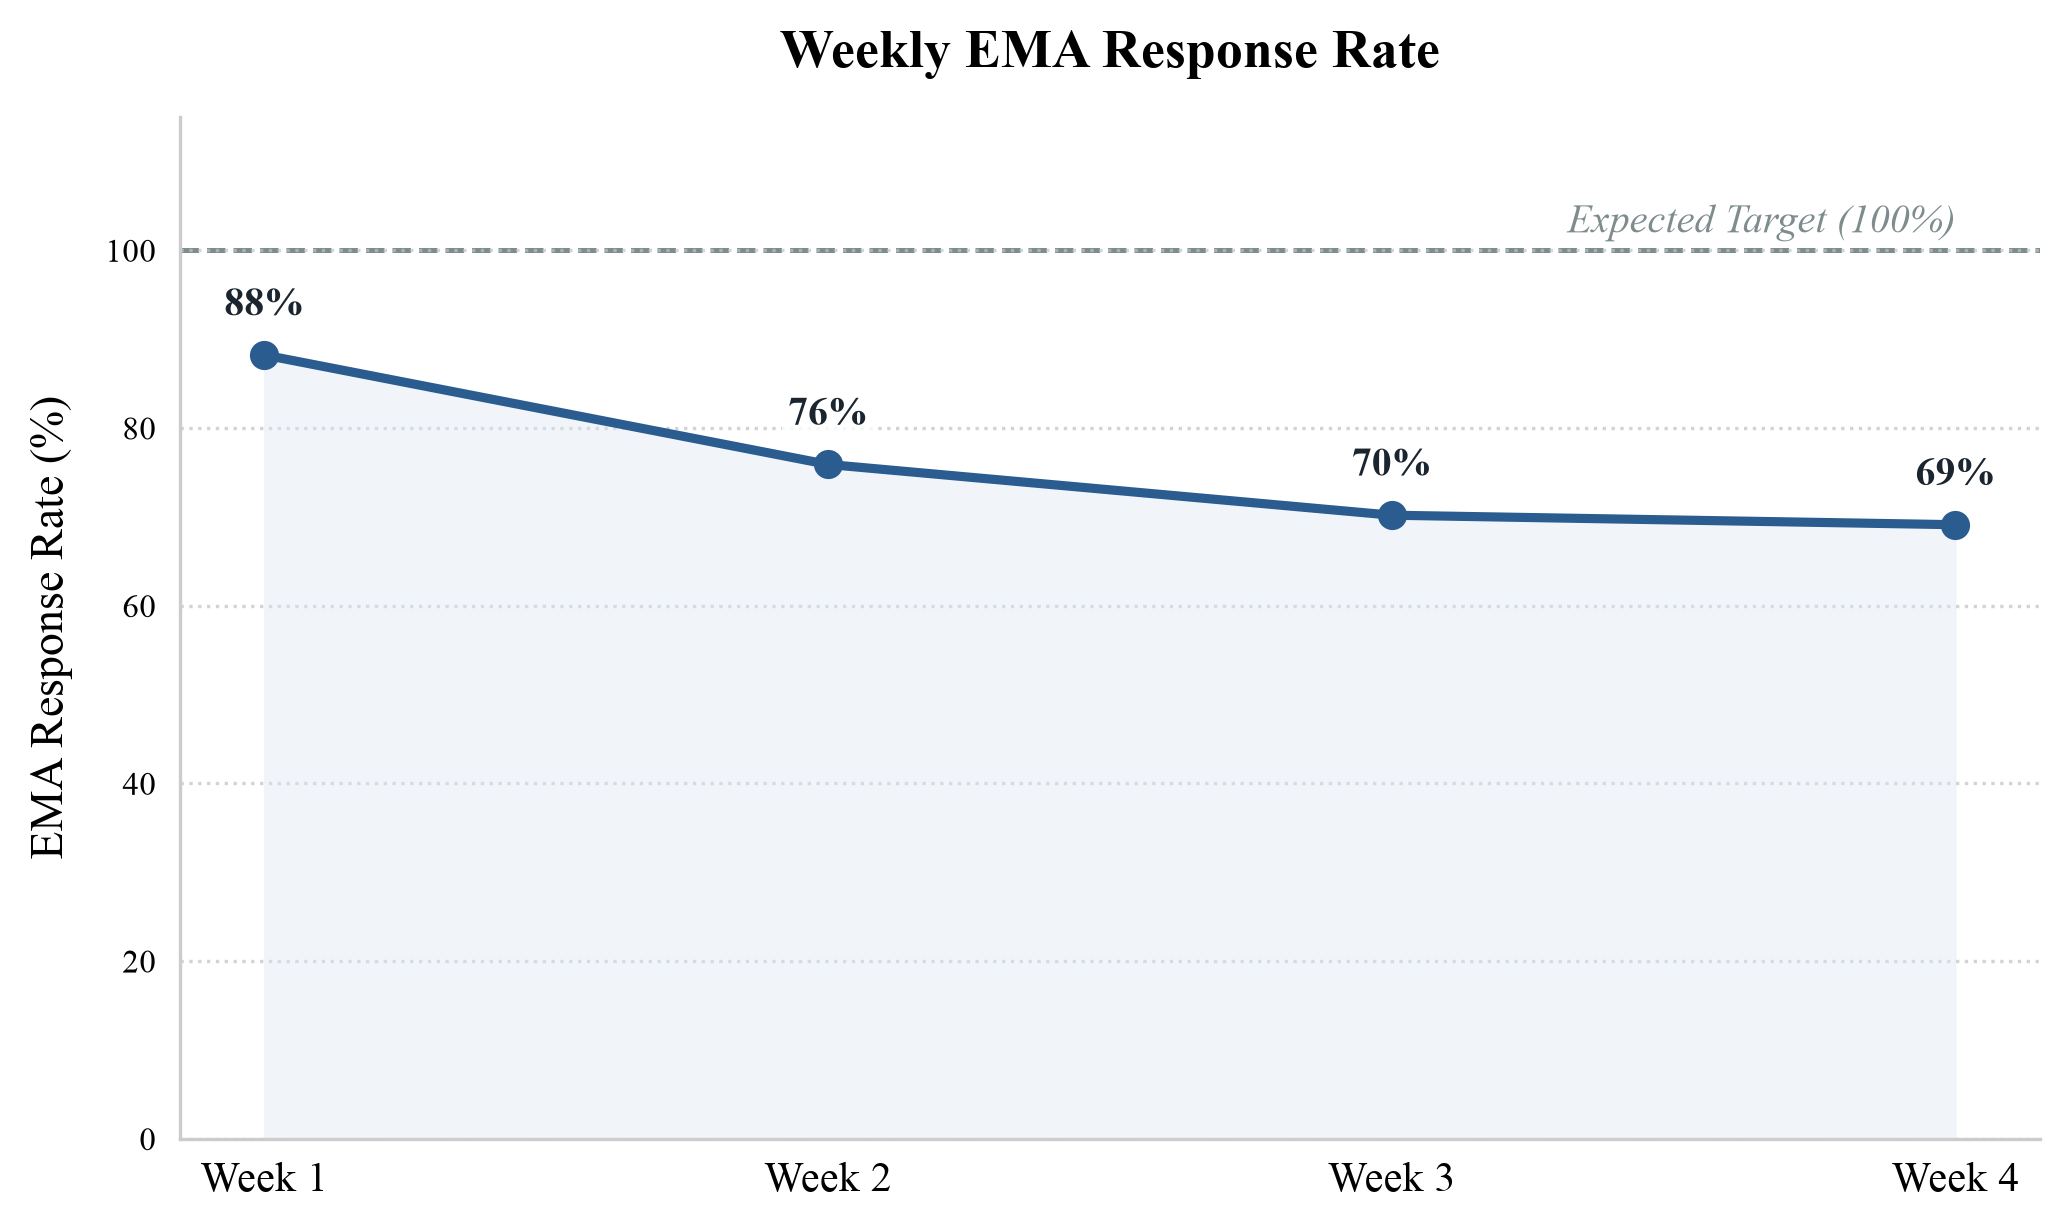

In [ ]:

plt.style.use("seaborn-v0_8-paper")

plt.rcParams["font.family"] = "Times New Roman"

fig, ax = plt.subplots(figsize=(7, 4.2), dpi=300)

x = range(len(WEEK_LABELS))
y = response_rate.values

line_color = "#2b5c8f"
fill_color = "#dce7f3"

ax.plot(
    x,
    y,
    marker="o",
    markersize=7,
    linewidth=2.2,
    color=line_color,
    zorder=3,
)

ax.fill_between(x, y, color=fill_color, alpha=0.4, zorder=2)

# 100% Expected Reference Line
ax.axhline(100, linestyle="--", linewidth=1.2, color="#7f8c8d", zorder=1)

ax.text(
    x[-1],
    101,
    " Expected Target (100%)",
    color="#7f8c8d",
    fontsize=9.5,
    fontstyle="italic",
    ha="right",
    va="bottom",
)

# Percentage Labels
for i, v in enumerate(y):
    ax.text(
        i,
        v + 3.5,
        f"{v:.0f}%",
        ha="center",
        va="bottom",
        fontsize=9.5,
        fontweight="bold",
        color="#1a252f",
        bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.8),
    )

# Axis 
ax.set_xticks(x)
ax.set_xticklabels(WEEK_LABELS, fontsize=10)
ax.set_ylabel("EMA Response Rate (%)", fontsize=11, labelpad=8)
ax.set_title("Weekly EMA Response Rate", fontsize=13, fontweight="bold", pad=12)

ax.set_ylim(0, 115)
ax.set_yticks(range(0, 101, 20))
ax.tick_params(axis="both", which="both", length=0)  # Hide tick marks for cleaner aesthetic


for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#cccccc")
    ax.spines[spine].set_linewidth(0.8)


ax.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.7, color="#bdc3c7", zorder=0)

plt.tight_layout()
plt.show()

In [64]:
n_users

40

In [65]:
ema

,id,app_user_id,survey_id,timestamp,notification_start,client_submission_id,study_day,week
0,1,5,0,2025-11-15 10:17:54.641,2025-11-15 10:17:54.648,NaN,1,Week 1
1,2,5,1,2025-11-15 17:52:03.295,2025-11-15 17:52:03.305,NaN,1,Week 1
2,3,5,0,2025-11-16 10:34:25.655,2025-11-16 10:34:25.660,NaN,2,Week 1
3,4,5,1,2025-11-16 17:03:13.659,2025-11-16 17:03:13.662,NaN,2,Week 1
4,5,5,0,2025-11-17 10:59:22.663,2025-11-17 10:59:22.673,NaN,3,Week 1
...,...,...,...,...,...,...,...,...
2169,2170,52,1,2026-09-06 18:41:14.290,2026-09-06 18:41:14.292,84941abb-8320-4913-845d-0b0c531f0403,5,Week 1
2170,2171,52,1,2026-09-07 18:29:23.583,2026-09-07 18:29:23.585,6760b86a-e0cd-4aa0-a5e9-453ba0d5e374,6,Week 1
2171,2172,52,0,2026-09-08 10:36:35.727,2026-09-08 10:36:35.728,5b29dc1a-60a4-4bb1-adc4-453dc6738191,7,Week 1
2172,2173,52,1,2026-09-08 16:59:21.592,2026-09-08 16:59:21.594,0c8af8a3-f336-4d54-9b4b-3b3a8ca623c2,7,Week 1


In [66]:
# Number of users who completed at least one EMA on Day 1
day1_users = ema.loc[ema["study_day"] == 1, "app_user_id"].nunique()

print("Total users:", n_users)
print("Users with EMA on Day 1:", day1_users)
print("Users missing EMA on Day 1:", n_users - day1_users)

Total users: 40
Users with EMA on Day 1: 39
Users missing EMA on Day 1: 1


In [67]:
day1 = ema[ema["study_day"] == 1]

print("Morning:", (day1["survey_id"] == 0.0).sum())
print("Afternoon:", (day1["survey_id"] == 1.0).sum())

Morning: 33
Afternoon: 38
